#Problem Statement - To identify the reasons and factors for customers leaving the bank


In [54]:
#importing required pacakges
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as  stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score
import joblib

In [5]:
#Reading the source CSV file
df = pd.read_csv('Bank-Records.csv')

#Data description
1) RowNumber—corresponds to the record (row) number and has no effect on the output.

2) CustomerId—contains random values and has no effect on customer leaving the bank.

3) Surname—the surname of a customer has no impact on their decision to leave the bank.

4) CreditScore—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.

5) Geography—a customer’s location can affect their decision to leave the bank.

6) Gender—it’s interesting to explore whether gender plays a role in a customer leaving the bank.

7) Age—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.

8) Tenure—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.

9) Balance—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.

10) NumOfProducts—refers to the number of products that a customer has  
    purchased through the bank.

11) HasCrCard—denotes whether or not a customer has a credit card. This column  
    is also relevant, since people with a credit card are less likely to leave the bank.

12) IsActiveMember—active customers are less likely to leave the bank.

13) EstimatedSalary—as with balance, people with lower salaries are more likely
    to leave the bank compared to those with higher salaries.

14) Exited—whether or not the customer left the bank.

15)Complain—customer has complaint or not.

16)Satisfaction Score—Score provided by the customer for their complaint    
   resolution.

17)Card Type—type of card hold by the customer.

18)Points Earned—the points earned by the customer for using credit card.


#Initial data Exploration

In [6]:
#top 20 rows of the data frame
df.head(20)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,1,5,DIAMOND,484
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0,0,2,SILVER,206
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,1,2,DIAMOND,282
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,0,3,GOLD,251
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0,0,3,GOLD,342


In [7]:
#information of the columns and rows
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [8]:
# finding out null values in the dataset
null_values_df = df.isnull().sum()

In [9]:
null_values_df

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

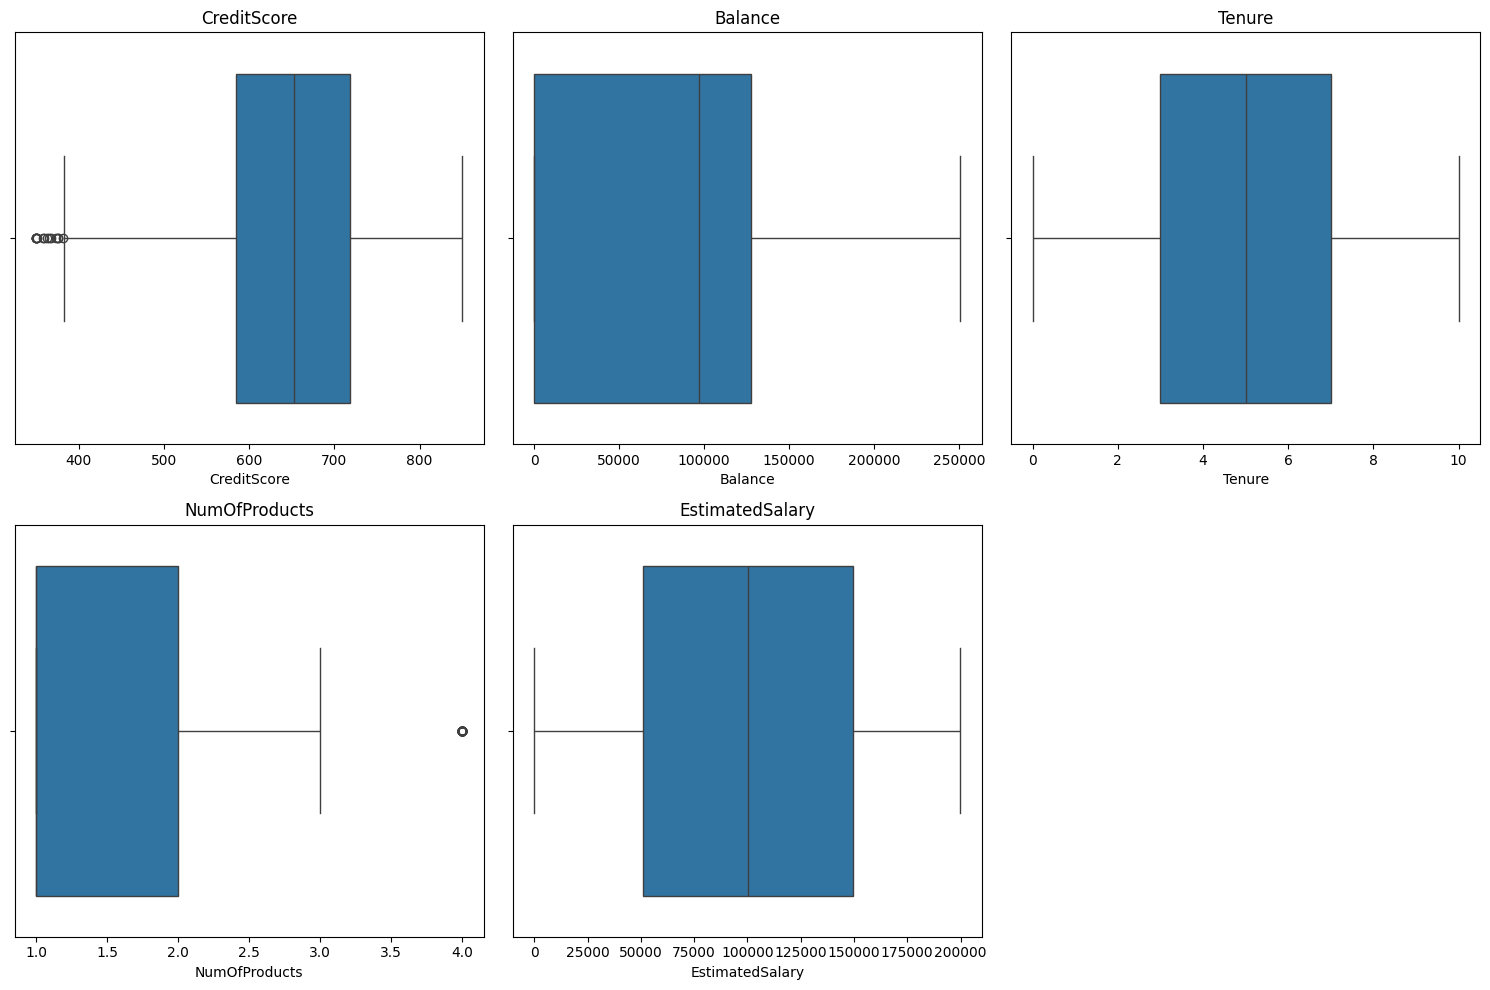

In [10]:
#checking for outliers in the column - creditscore ,balance , tenure ,num of products ,estimated salary




columns = ['CreditScore', 'Balance', 'Tenure', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns

for i, ax in enumerate(axes.flatten()):
    if i < len(columns):
        sns.boxplot(x=df[columns[i]], ax=ax)
        ax.set_title(columns[i])
    else:
        fig.delaxes(ax)

plt.tight_layout()
plt.show()




There are outliers in Creditscore which are closer to each other and are below 400.

#Checking for Correlation of different columns with Exited Column.

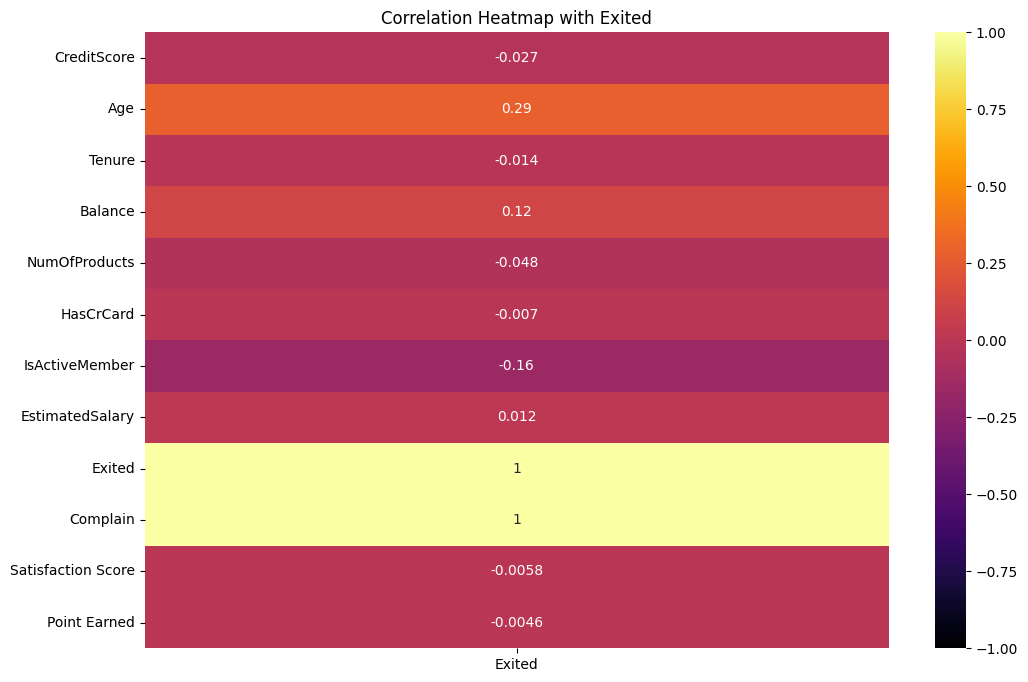

In [11]:

columns_to_exclude = ['RowNumber', 'CustomerId','Surname','Geography','Gender','Card Type']

# Drop the excluded columns from the DataFrame
df_excluded = df.drop(columns_to_exclude, axis=1)

# Calculate correlation matrix
correlation_matrix = df_excluded.corr()

# Sort correlation matrix by correlation with "Exited" column
correlation_with_exited = correlation_matrix['Exited'].sort_values(ascending=False)


plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix[['Exited']], annot=True, cmap='inferno', vmin=-1, vmax=1)
plt.title('Correlation Heatmap with Exited')
plt.show()


Actionable Insight : From above heatmap we can see that complain,age,balance these columns are very relatable to our important column of exited which shows they would have valuable insight to provide why customer are churning

# Checking relationship of customer exiting bank according to there credit information

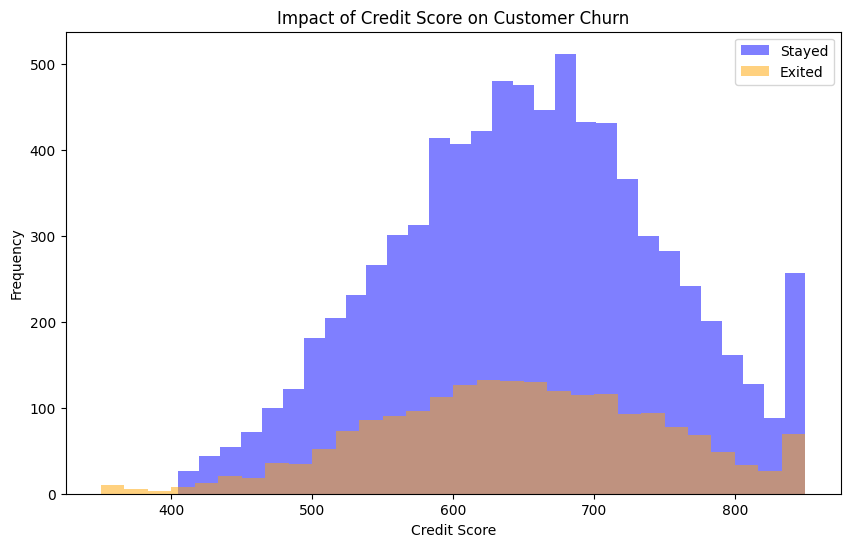

In [12]:
# Filter the DataFrame for customers who stayed and those who exited
stayed_credit_score = df[df['Exited'] == 0]['CreditScore']
exited_credit_score = df[df['Exited'] == 1]['CreditScore']


plt.figure(figsize=(10, 6))

# Plot histogram for customers who stayed
plt.hist(stayed_credit_score, bins=30, alpha=0.5, color='blue', label='Stayed')

# Plot histogram for customers who exited
plt.hist(exited_credit_score, bins=30, alpha=0.5, color='orange', label='Exited')


plt.title('Impact of Credit Score on Customer Churn')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.legend()


plt.show()

Actional_Insight: From the above histogram it is clear that people with higher credit score are churing as seen in credit score between 600 to 700 ,But the number of customers who have higher credit score in the same bracke of (600-700)are staying with bank and there frequency is higher than customers those who are churning.



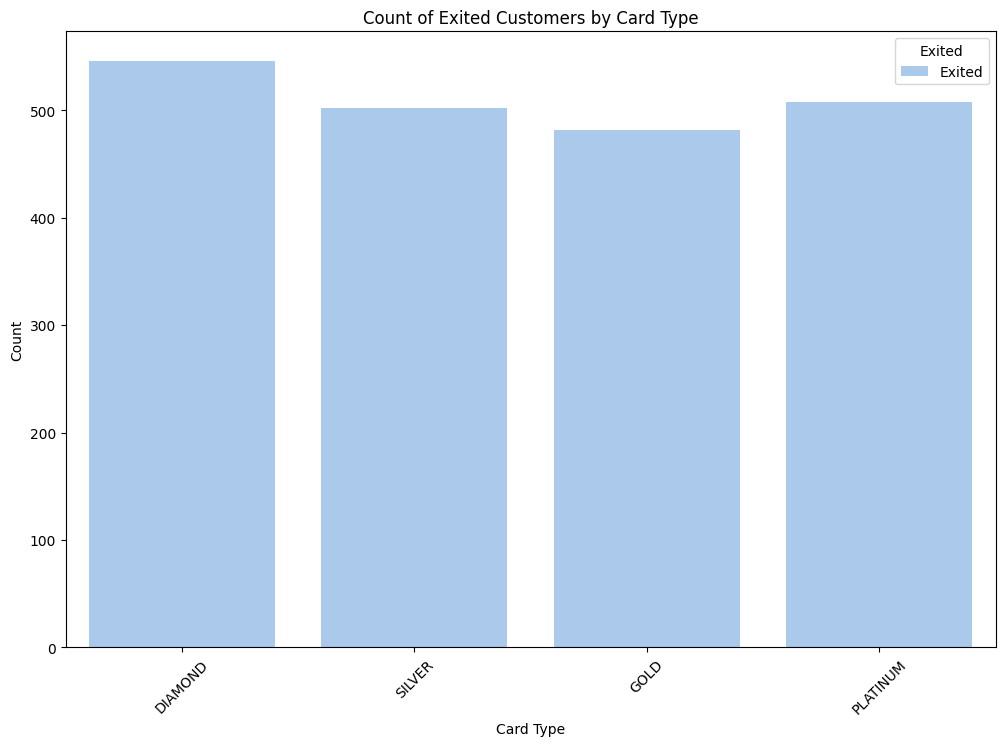

In [13]:
exited_df = df[df['Exited'] == 1]
plt.figure(figsize=(12, 8))
sns.countplot(x='Card Type', hue='Exited', data=exited_df,palette='pastel')
plt.title('Count of Exited Customers by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Exited'])
plt.xticks(rotation=45)
plt.show()

Actional_Insight:

As seen customers with Diamond card type are churning more than other card .

Recommendation:

Evaluate the benefits and perks offered with the Diamond card type. Consider whether they align with customer expectations and needs. If necessary, enhance the benefits to increase customer satisfaction and retention.


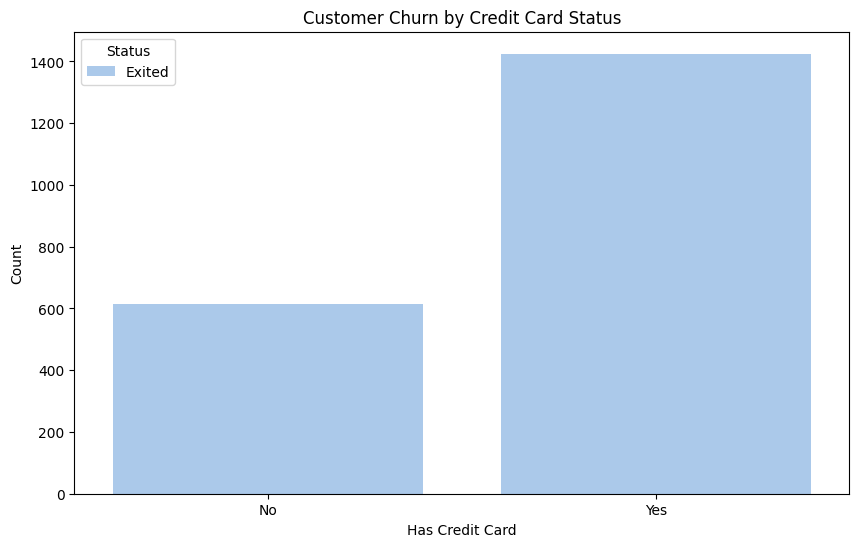

In [14]:
exited_df = df[df['Exited'] == 1]
plt.figure(figsize=(10, 6))
sns.countplot(x='HasCrCard', hue='Exited', data=exited_df, palette='pastel')
plt.title('Customer Churn by Credit Card Status')
plt.xlabel('Has Credit Card')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.legend(title='Status', labels= ['Exited'])
plt.show()

Actional_Insight:

Customer's those who have credit cards are churning more than customers who do not posses one .

Recommendation:

 Explore cross-selling opportunities to deepen relationships with credit cardholders. Offer complementary products and services such as savings accounts, loans, or investment options to increase customer engagement and loyalty.



C:\Users\dev\AppData\Local\Temp\ipykernel_5348\2965183775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='EstimatedSalary', data=df, palette='pastel')


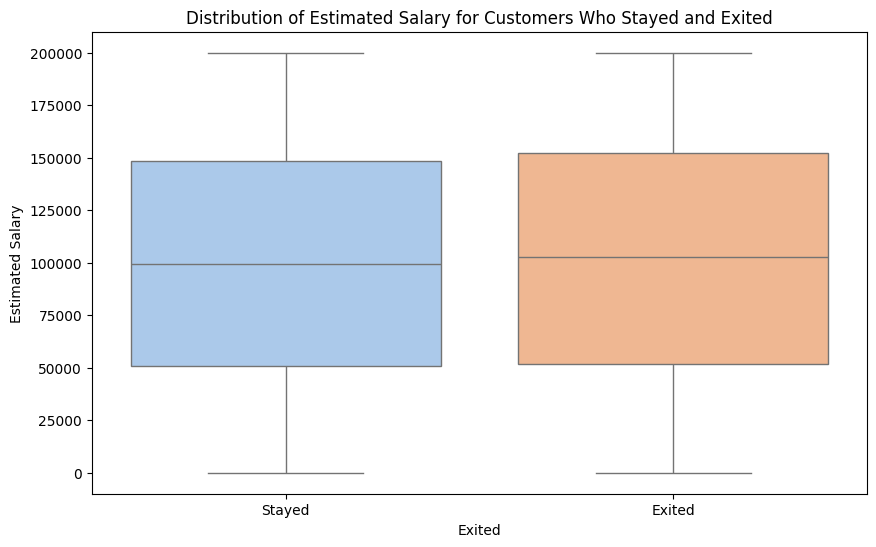

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Exited', y='EstimatedSalary', data=df, palette='pastel')
plt.title('Distribution of Estimated Salary for Customers Who Stayed and Exited')
plt.xlabel('Exited')
plt.ylabel('Estimated Salary')
plt.xticks(ticks=[0, 1], labels=['Stayed', 'Exited'])
plt.show()

Actional_Insight: Estimated salary didn't have much impact on customer churning as same salary range people some prefered to stay with the bank and some churned away



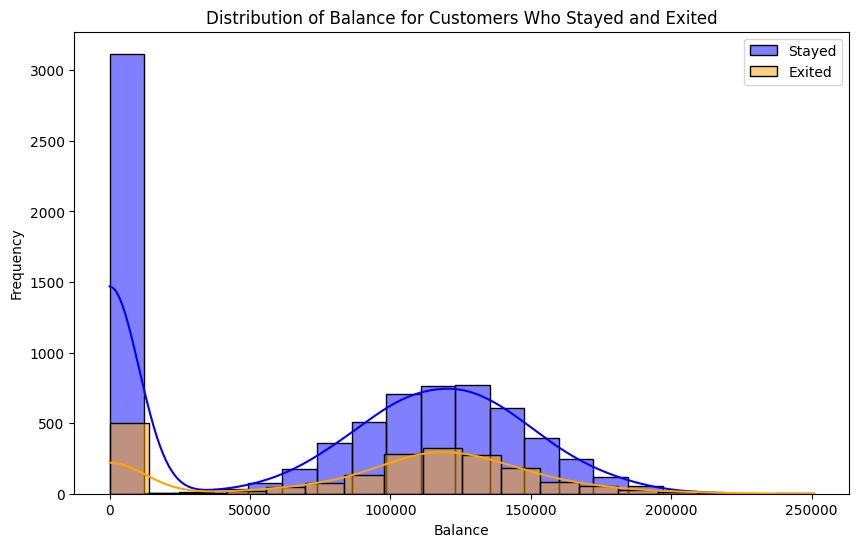

In [16]:

# Filter DataFrame for customers who stayed and those who exited
stayed_balance = df[df['Exited'] == 0]['Balance']
exited_balance = df[df['Exited'] == 1]['Balance']


plt.figure(figsize=(10, 6))
sns.histplot(stayed_balance, color='blue', label='Stayed', kde=True)
sns.histplot(exited_balance, color='orange', label='Exited', kde=True)
plt.title('Distribution of Balance for Customers Who Stayed and Exited')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Actional_Insight:

Customers keeping zero balance in there accounts are churning more than customers having some amount of balance in the account with the bank.

Recommendation:


*  Offer incentives to encourage customers to maintain a minimum balance in their accounts. This could include waiving fees, offering rewards, or providing interest on balances to incentivize account activity.


* Implement automated alerts to notify customers when their account balance is low or approaching zero. This proactive approach can remind customers to replenish their accounts and reduce the likelihood of churn due to inactivity.   




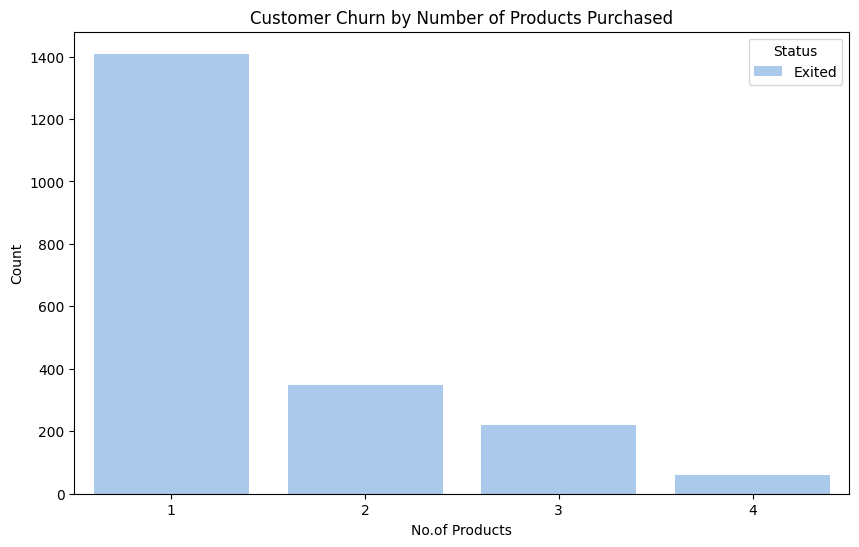

In [17]:
exited_df = df[df['Exited'] == 1]
plt.figure(figsize=(10, 6))
sns.countplot(x='NumOfProducts', hue='Exited', data=exited_df, palette='pastel')
plt.title('Customer Churn by Number of Products Purchased')
plt.xlabel('No.of Products')
plt.ylabel('Count')

plt.legend(title='Status', labels= ['Exited'])
plt.show()

Actional_Insight:
Customers buying Less Number of Products are churing more than Customers buying more products.

Recommendation:

 1) Encourage customers to purchase multiple products by offering bundle discounts or incentives. Bundling products such as checking accounts, savings accounts, credit cards, and loans can increase the perceived value for customers and incentivize them to stay with the bank.

 2) Reach out to customers who have only purchased a few products to understand their needs and encourage them to explore additional offerings. Proactive engagement can demonstrate the bank's commitment to meeting customer needs and foster loyalty.

#Demographic Analysis by Gender , Geography and Age

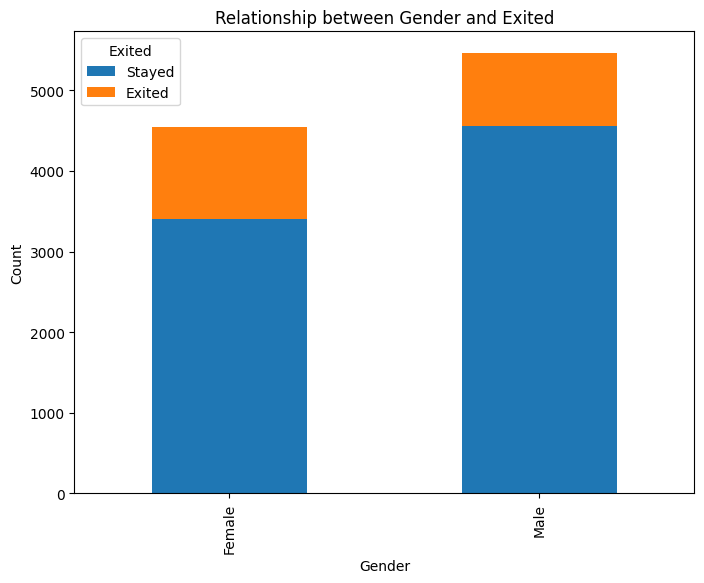

In [18]:


# Group by 'gender' and calculate the count of 'exited' values
grouped = df.groupby(['Gender', 'Exited']).size().unstack()

# Plotting
grouped.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Relationship between Gender and Exited')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Exited'])
plt.show()


Actional_Insight:
Males customers are higher in number to stay with bank and females customers  are churing more than male customers .

Recommendation:



*   Develop gender-specific marketing strategies tailored to the needs and preferences of male and female customers. Use demographic data and customer insights to create targeted messaging and promotions that resonate with each gender group.

*   Evaluate the bank's product offerings to ensure they meet the needs of both male and female customers. Consider offering products and services that appeal to each gender group, taking into account differences in financial goals, spending habits, and risk tolerance



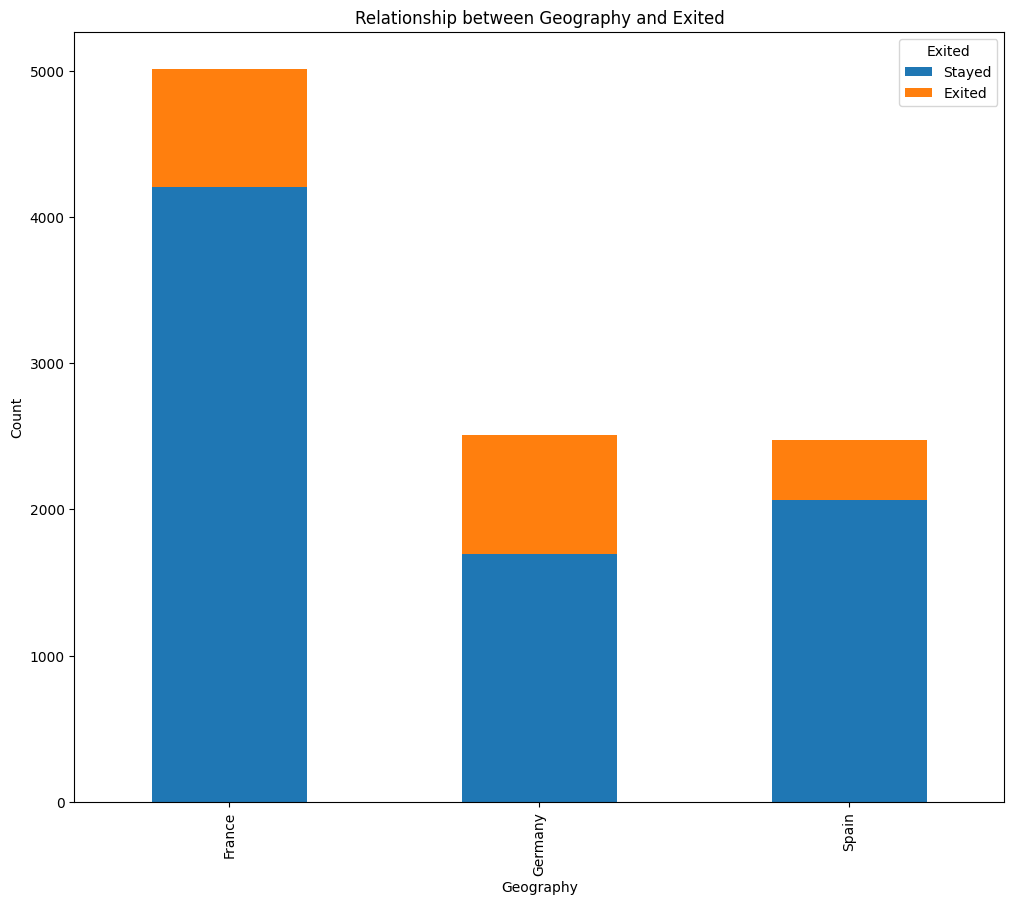

In [19]:
grouped_geo = df.groupby(['Geography', 'Exited']).size().unstack()

grouped_geo.plot(kind='bar', stacked=True, figsize=(12, 10))
plt.title('Relationship between Geography and Exited')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Exited'])
plt.show()

Actional_Insight:

Customer in France are more retained with the bank than any other country and customer churning is higher in germany than other 2 countries.

Recommendation:



*   Tailor retention strategies to the specific needs and preferences of customers in each country. Invest more resources in retention efforts in Germany to address the higher churn rate, while maintaining customer satisfaction and loyalty in France through targeted retention initiatives.


* Conduct market research to understand the factors driving customer retention in France and churn in Germany. Gather insights into cultural differences, regulatory environments, and competitive landscapes to inform strategic decision-making and prioritize retention efforts.



C:\Users\dev\AppData\Local\Temp\ipykernel_5348\3517669126.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age_ext_flt['Age Group'] = pd.cut(df_age_ext_flt['Age'],bins =[20,30,40,50,60,70,80,90,100],labels=['20-30', '31-40', '41-50', '51-60', '61-70','71-80','81-90','91-100'])


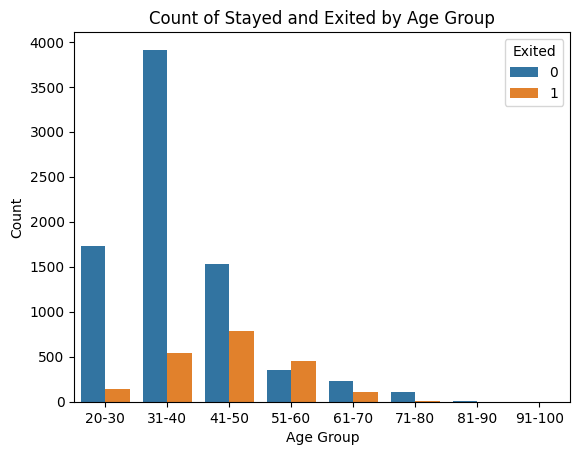

In [20]:
df_age_ext_flt = df[['Age','Exited']]
# Create age buckets
df_age_ext_flt['Age Group'] = pd.cut(df_age_ext_flt['Age'],bins =[20,30,40,50,60,70,80,90,100],labels=['20-30', '31-40', '41-50', '51-60', '61-70','71-80','81-90','91-100'])
# Create a countplot
sns.countplot(x = 'Age Group',hue = 'Exited',data = df_age_ext_flt)
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Count of Stayed and Exited by Age Group")

plt.show()

Actional_Insight:

Customers at the age of 40 to 50 are churing away more and customers at age of 30 to 40 are staying with bank

Recommendation:

 * Develop targeted retention campaigns specifically aimed at customers aged 40 to 50. Identify the reasons for their churn and tailor retention offers and incentives to address their needs and concerns.

 * Offer financial planning workshops and seminars targeted at customers aged 40 to 50. Provide guidance on retirement planning, investment strategies, and wealth management to help them achieve their long-term financial goals and strengthen their relationship with the bank.

#Checking Customer Levaing bank according to the tenure ,complain status,activity

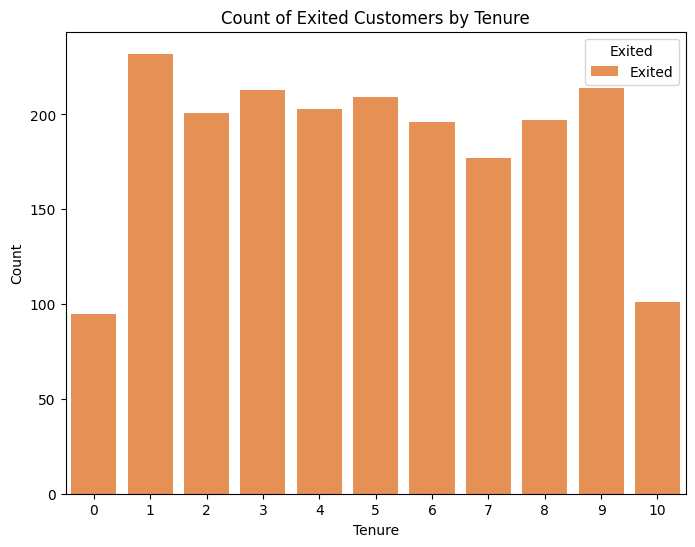

In [21]:


exited_df = df[df['Exited'] == 1]
plt.figure(figsize=(8, 6))
sns.countplot(x='Tenure', hue='Exited', data=exited_df,palette='Oranges')
plt.title('Count of Exited Customers by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Exited'])
plt.show()


Actional_Insight:

Customers with higher Tenure with bank are less likely to churn and customer with 1 year tenure with the bank are churing more.


Recommendation:

Develop personalized retention offers targeted at customers with a tenure of 1 year to mitigate churn risk. Offer incentives such as fee waivers, account upgrades, or bonus rewards to encourage them to continue their relationship with the bank beyond the initial year.


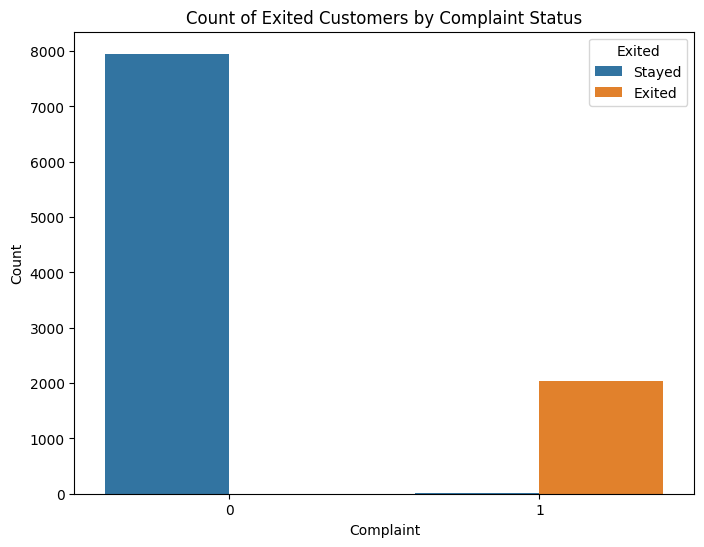

In [22]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Complain', hue='Exited', data=df)
plt.title('Count of Exited Customers by Complaint Status')
plt.xlabel('Complaint')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Stayed', 'Exited'])
plt.show()

In [23]:
df['Complain'].value_counts()

Complain
0    7956
1    2044
Name: count, dtype: int64

Actional_Insight:
Almost all the customers those who have complained have left the bank which is around 2000 .

Recommendation:

* Conduct a thorough review of the bank's complaint resolution process to identify areas for improvement. Ensure that complaints are handled promptly, efficiently, and to the satisfaction of the customer.

* Implement proactive customer support initiatives to prevent complaints before they occur. Provide clear channels for customers to voice their concerns and feedback, and address issues proactively to prevent escalation.

* Conduct root cause analysis to identify the underlying reasons for customer complaints. Address systemic issues within the bank's operations, processes, or products that are leading to recurring complaints and customer dissatisfaction.


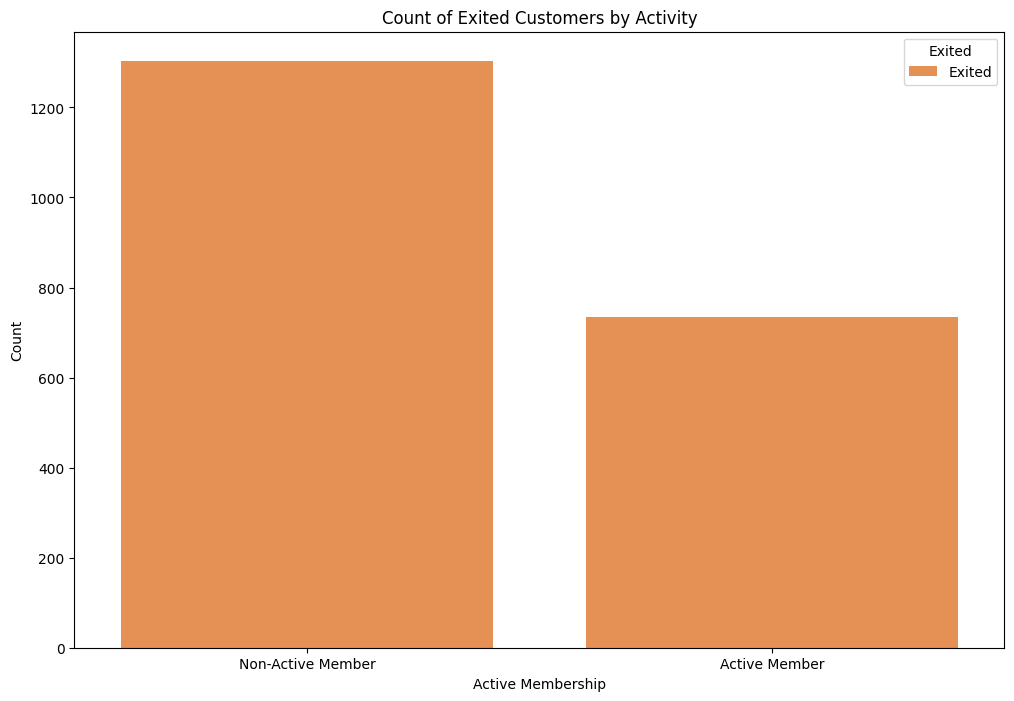

In [24]:
exited_df = df[df['Exited'] == 1]
plt.figure(figsize=(12, 8))
sns.countplot(x='IsActiveMember', hue='Exited', data=exited_df, palette='Oranges')
plt.title('Count of Exited Customers by Activity')
custom_labels = ['Non-Active Member', 'Active Member']
plt.xticks(ticks=[0, 1], labels=custom_labels)
plt.xlabel('Active Membership')
plt.ylabel('Count')
plt.legend(title='Exited', labels=['Exited'])

plt.show()

Actional_Insight:

Non Active Members churing is more than Active members

Recommendation:

* Implement re-engagement campaigns targeted at non-active members to encourage them to become more active with the bank. Offer incentives, such as bonus rewards or discounts, to entice non-active members to start using their accounts and engaging with bank services again.

* Use personalized communication strategies to reach out to non-active members and understand the reasons behind their inactivity. Tailor messaging based on their previous interactions with the bank and offer relevant solutions or assistance to address their needs and concerns.

* Conduct account reviews for non-active members to identify opportunities to optimize their banking experience. Offer suggestions for products or services that align with their financial goals and lifestyle, and provide guidance on how they can make the most of their accounts.



##Statistical Testing

###Hypotheses testing for "Age","Credit Score","Balance","Estimated Salary"

In [25]:
# Split by churn
age_churn = df[df['Exited'] == 1]['Age']
age_not_churn = df[df['Exited'] == 0]['Age']

# Normality check

stat1, p1 = stats.shapiro(age_churn.sample(min(len(age_churn),500)))
stat2, p2 = stats.shapiro(age_not_churn.sample(min(len(age_not_churn),500)))
# if p value is greater than 0.5 then we assume data is normally distributed
# if p value is less than 0.05 we assume data is not normally distributed


if p1 > 0.05 and p2 > 0.05:
  #h0: The distribution of age is the same for customers who exited and those who did not
  #ha: The distribution of Age is different between customers who exited and those who did not.
  stat,p_val = stats.ttest_ind(age_churn,age_not_churn,equal_var=False)
  if p_val <0.05:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'H0'} ")
else:
  stat,p_val = stats.mannwhitneyu(age_churn,age_not_churn,alternative='two-sided')
  if p_val < 0.05:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'H0'} ")

Mann -Whitney: p-value = 2.7802649610221583e-230 and Hypotheses accepted : Ha 


In [26]:
# Split by churn
bal_churn = df[df['Exited'] == 1]['Balance']
bal_not_churn = df[df['Exited'] == 0]['Balance']

# Normality check

stat1, p1 = stats.shapiro(bal_churn.sample(min(len(bal_churn),500)))
stat2, p2 = stats.shapiro(bal_not_churn.sample(min(len(bal_not_churn),500)))
# if p value is greater than 0.5 then we assume data is normally distributed
# if p value is less than 0.05 we assume data is not normally distributed


if p1 > 0.05 and p2 > 0.05:
  #h0: The distribution of Balance is the same for customers who exited and those who did not
  #ha: The distribution of Balance is different between customers who exited and those who did not.
  stat,p_val = stats.ttest_ind(bal_churn,bal_not_churn,equal_var=False)
  if p_val <0.05:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'H0'} ")
else:
  stat,p_val = stats.mannwhitneyu(bal_churn,bal_not_churn,alternative='two-sided')
  if p_val < 0.05:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'H0'} ")

Mann -Whitney: p-value = 1.1687654686289807e-28 and Hypotheses accepted : Ha 


In [27]:
# H0: Gender and Exited are independent (no association between gender and churn).
# Ha: Gender and Exited are dependent (gender affects churn).

contigency = pd.crosstab(df['Gender'],df['Exited'])

chi2,p_val,dof,expected = stats.chi2_contingency(contigency)
if p_val < 0.05:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
else:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'H0'}")

Chi-square: p-value = 2.9253677618642e-26 and Hypotheses accepted : Ha 


In [28]:
# H0: Geography and Exited are independent (no association between geography and churn).
# Ha: Geography and Exited are dependent (geography affects churn).

contigency = pd.crosstab(df['Geography'],df['Exited'])

chi2,p_val,dof,expected = stats.chi2_contingency(contigency)
if p_val < 0.05:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
else:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'H0'}")

Chi-square: p-value = 5.245736109572763e-66 and Hypotheses accepted : Ha 


In [29]:
# H0: presence of credit card and Exited are independent (no association between presence of credit card and churn).
# Ha: presence of credit card and Exited are dependent (presence of credit card has  affects on churn).

contigency = pd.crosstab(df['HasCrCard'],df['Exited'])

chi2,p_val,dof,expected = stats.chi2_contingency(contigency)
if p_val < 0.05:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
else:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'H0'}")

Chi-square: p-value = 0.5026181509009862 and Hypotheses accepted : H0


In [30]:
# Split by churn
Ten_churn = df[df['Exited'] == 1]['Tenure']
Ten_not_churn = df[df['Exited'] == 0]['Tenure']

# Normality check

stat1, p1 = stats.shapiro(Ten_churn.sample(min(len(Ten_churn),500)))
stat2, p2 = stats.shapiro(Ten_not_churn.sample(min(len(Ten_not_churn),500)))
# if p value is greater than 0.5 then we assume data is normally distributed
# if p value is less than 0.05 we assume data is not normally distributed


if p1 > 0.05 and p2 > 0.05:
  #h0: The distribution of Tenure is the same for customers who exited and those who did not
  #ha: The distribution of Tenure is different between customers who exited and those who did not.
  stat,p_val = stats.ttest_ind(Ten_churn,Ten_not_churn,equal_var=False)
  if p_val <0.05:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'H0'} ")
else:
  stat,p_val = stats.mannwhitneyu(Ten_churn,Ten_not_churn,alternative='two-sided')
  if p_val < 0.05:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'H0'} ")

Mann -Whitney: p-value = 0.1729583374544681 and Hypotheses accepted : H0 


In [31]:
# Split by churn
pro_churn = df[df['Exited'] == 1]['NumOfProducts']
pro_not_churn = df[df['Exited'] == 0]['NumOfProducts']

# Normality check

stat1, p1 = stats.shapiro(pro_churn.sample(min(len(pro_churn),500)))
stat2, p2 = stats.shapiro(pro_not_churn.sample(min(len(pro_not_churn),500)))
# if p value is greater than 0.5 then we assume data is normally distributed
# if p value is less than 0.05 we assume data is not normally distributed


if p1 > 0.05 and p2 > 0.05:
  #h0: The distribution of Numof-Product  is the same for customers who exited and those who did not
  #ha: The distribution of Numof-Product is different between customers who exited and those who did not.
  stat,p_val = stats.ttest_ind(pro_churn,pro_not_churn,equal_var=False)
  if p_val <0.05:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'H0'} ")
else:
  stat,p_val = stats.mannwhitneyu(pro_churn,pro_not_churn,alternative='two-sided')
  if p_val < 0.05:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'H0'} ")

Mann -Whitney: p-value = 7.27941525191311e-36 and Hypotheses accepted : Ha 


In [32]:
# H0: Active member and Exited are independent (no association between Active Member and churn).
# Ha: Active Member and Exited are dependent (Active Member has affects on churn).

contigency = pd.crosstab(df['IsActiveMember'],df['Exited'])

chi2,p_val,dof,expected = stats.chi2_contingency(contigency)
if p_val < 0.05:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
else:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'H0'}")

Chi-square: p-value = 6.153167438113408e-55 and Hypotheses accepted : Ha 


In [33]:
# H0: Card Type and Exited are independent (no association between Card Type and churn).
# Ha: Card Type and Exited are dependent (Card Type has affects on churn).

contigency = pd.crosstab(df['Card Type'],df['Exited'])

chi2,p_val,dof,expected = stats.chi2_contingency(contigency)
if p_val < 0.05:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
else:
  print(f"Chi-square: p-value = {p_val} and Hypotheses accepted : {'H0'}")

Chi-square: p-value = 0.16794112067810177 and Hypotheses accepted : H0


In [34]:
# Split by churn
sal_churn = df[df['Exited'] == 1]['EstimatedSalary']
sal_not_churn = df[df['Exited'] == 0]['EstimatedSalary']

# Normality check

stat1, p1 = stats.shapiro(pro_churn.sample(min(len(sal_churn),500)))
stat2, p2 = stats.shapiro(pro_not_churn.sample(min(len(sal_not_churn),500)))
# if p value is greater than 0.5 then we assume data is normally distributed
# if p value is less than 0.05 we assume data is not normally distributed


if p1 > 0.05 and p2 > 0.05:
  #h0: The distribution of Numof-Product  is the same for customers who exited and those who did not
  #ha: The distribution of Numof-Product is different between customers who exited and those who did not.
  stat,p_val = stats.ttest_ind(sal_churn,sal_not_churn,equal_var=False)
  if p_val <0.05:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'H0'} ")
else:
  stat,p_val = stats.mannwhitneyu(sal_churn,sal_not_churn,alternative='two-sided')
  if p_val < 0.05:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'H0'} ")

Mann -Whitney: p-value = 0.21235576456250627 and Hypotheses accepted : H0 


In [35]:
# Split by churn
pt_churn = df[df['Exited'] == 1]['Point Earned']
pt_not_churn = df[df['Exited'] == 0]['Point Earned']

# Normality check

stat1, p1 = stats.shapiro(pro_churn.sample(min(len(pt_churn),500)))
stat2, p2 = stats.shapiro(pro_not_churn.sample(min(len(pt_not_churn),500)))
# if p value is greater than 0.5 then we assume data is normally distributed
# if p value is less than 0.05 we assume data is not normally distributed


if p1 > 0.05 and p2 > 0.05:
  #h0: The distribution of Points Earned  is the same for customers who exited and those who did not
  #ha: The distribution of Points Earned is different between customers who exited and those who did not.
  stat,p_val = stats.ttest_ind(pt_churn,pt_not_churn,equal_var=False)
  if p_val <0.05:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'H0'} ")
else:
  stat,p_val = stats.mannwhitneyu(pt_churn,pt_not_churn,alternative='two-sided')
  if p_val < 0.05:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'H0'} ")

Mann -Whitney: p-value = 0.6595122287415172 and Hypotheses accepted : H0 


In [36]:
df.head(0)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned


In [37]:
# Split by churn
cr_churn = df[df['Exited'] == 1]['CreditScore']
cr_not_churn = df[df['Exited'] == 0]['CreditScore']

# Normality check

stat1, p1 = stats.shapiro(cr_churn.sample(min(len(cr_churn),500)))
stat2, p2 = stats.shapiro(cr_not_churn.sample(min(len(cr_not_churn),500)))
# if p value is greater than 0.5 then we assume data is normally distributed
# if p value is less than 0.05 we assume data is not normally distributed


if p1 > 0.05 and p2 > 0.05:
  #h0: The distribution of Points Earned  is the same for customers who exited and those who did not
  #ha: The distribution of Points Earned is different between customers who exited and those who did not.
  stat,p_val = stats.ttest_ind(cr_churn,cr_not_churn,equal_var=False)
  if p_val <0.05:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
    print(f"T-test: p-value = {p_val} and Hypotheses accepted : {'H0'} ")
else:
  stat,p_val = stats.mannwhitneyu(cr_churn,cr_not_churn,alternative='two-sided')
  if p_val < 0.05:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'Ha'} ")
  else:
      print(f"Mann -Whitney: p-value = {p_val} and Hypotheses accepted : {'H0'} ")

Mann -Whitney: p-value = 0.02175071120128018 and Hypotheses accepted : Ha 


###selected columns after test are CreditScore,IsActive,NumOfProducts,Geography,Balance,Age

In [38]:
#Setting the traget column
target = 'Exited'

features = ['CreditScore','Age','Balance','NumOfProducts','IsActiveMember','Geography','Gender']

x = df[features]

y = df[target]


In [39]:
categorical = ['Geography','Gender']
numerical = ['CreditScore','Age','Balance','NumOfProducts','IsActiveMember']

In [40]:
preprocessor = ColumnTransformer(
    transformers = [('num',StandardScaler(),numerical),
                    ('cat',OneHotEncoder(drop='first'),categorical)]
)

In [41]:
log_reg = Pipeline(steps = [('preprocessor',preprocessor),
                            ('model',LogisticRegression(max_iter=1000,random_state=42))
                            ])


In [42]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


In [43]:
log_reg.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
y_pred =  log_reg.predict(x_test)
y_prob = log_reg.predict_proba(x_test)[:,1]

In [45]:
# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[1544   48]
 [ 327   81]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.63      0.20      0.30       408

    accuracy                           0.81      2000
   macro avg       0.73      0.58      0.60      2000
weighted avg       0.78      0.81      0.77      2000


ROC-AUC Score: 0.7790391910533058


In [46]:
feature_names = numerical + list(log_reg.named_steps['preprocessor']
                               .named_transformers_['cat']
                               .get_feature_names_out(categorical))

coefficients = log_reg.named_steps['model'].coef_[0]
importance_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
importance_df['Odds_Ratio'] = np.exp(coefficients)
importance_df = importance_df.sort_values(by='Odds_Ratio', ascending=False)

print("\nFeature Importance (Odds Ratios):\n", importance_df)


Feature Importance (Odds Ratios):
              Feature  Coefficient  Odds_Ratio
5  Geography_Germany     0.816741    2.263112
1                Age     0.739096    2.094042
2            Balance     0.164342    1.178617
6    Geography_Spain     0.049175    1.050404
3      NumOfProducts    -0.057040    0.944557
0        CreditScore    -0.078677    0.924339
4     IsActiveMember    -0.504408    0.603863
7        Gender_Male    -0.530291    0.588434


In [58]:
# saving Logistic_Regression
joblib.dump(log_reg,'models/LogisticRegression_Model.pkl') 

['models/LogisticRegression_Model.pkl']

## XG Boost

In [47]:
xgb = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.1,
    max_depth = 4,
    scale_pos_weight = len(y[y==0])/len(y[y==1]),
    use_label_encoder = False,
    eval_metric ='logloss',
    random_state = 42
)

In [48]:
xgb_pipeline =Pipeline(steps =[
    ('preprocessor',preprocessor),
    ("Model",xgb)

])

In [49]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state =42,stratify=y)

In [50]:
xgb_pipeline.fit(x_train,y_train)

c:\Users\dev\Desktop\Churning_Bank_Customer\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:48:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('preprocessor', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
y_pred = xgb_pipeline.predict(x_test)
y_prob = xgb_pipeline.predict_proba(x_test)[:,1]

In [52]:
#Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[1292  300]
 [  96  312]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.87      1592
           1       0.51      0.76      0.61       408

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.82      2000


ROC-AUC Score: 0.8742825647847079


In [53]:
# important features
importances = xgb.feature_importances_
feature_names = numerical + list(
    xgb_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical)
)
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("\nFeature Importances:\n", importance_df)


Feature Importances:
              Feature  Importance
3      NumOfProducts    0.284655
4     IsActiveMember    0.195756
1                Age    0.169498
5  Geography_Germany    0.133743
7        Gender_Male    0.083796
2            Balance    0.061649
6    Geography_Spain    0.035664
0        CreditScore    0.035240


In [59]:
# Saving XG boost

joblib.dump(xgb_pipeline,"models/XG_Boost.pkl")

print("Model saved")

Model saved
